**This program is executed using Google colab**

## Library import


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

## Checking configurations

In [2]:
tf.config.experimental.list_physical_devices()
# Checking the list of physical devices used by tensorflow

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
tf.test.is_built_with_cuda()

True

## Data import


[DATASET INFO](https://www.cs.toronto.edu/%7Ekriz/cifar.html)

In [4]:
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 [==============================] - 16s 0us/step


## EDA(exploratory data analysis)


In [5]:
x_train.shape

(50000, 32, 32, 3)

50000 records  
32 x 32 dimension  
3 is color dimension like RGB

In [6]:
x_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [7]:
x_train[0].shape

(32, 32, 3)

In [8]:
y_train[0]

array([6], dtype=uint8)

In [9]:
def plot_sample(index):
    plt.figure(figsize=(10,1))
    plt.imshow(x_train[index])

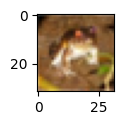

In [10]:
plot_sample(0)

In [11]:
classes  = ['airplane','automobile','bird','cat','deer','dog',
            'frog','horse','ship','truck']

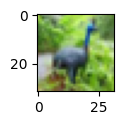

In [12]:
plot_sample(6)

In [13]:
y_train[6]

array([2], dtype=uint8)

In [14]:
classes[y_train[6][0]]

'bird'

In [15]:
x_train = x_train/255
x_test = x_test/255

## One Hot Encoding NN

In [16]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [17]:
y_train_categorical = keras.utils.to_categorical(
    y_train,num_classes = 10
)
y_train_categorical[:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [18]:
y_test_categorical = keras.utils.to_categorical(
    y_test,num_classes = 10
)

## Model Building

In [20]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(3000,activation='relu'),
    keras.layers.Dense(3000,activation = 'relu'),
    keras.layers.Dense(10,activation = 'sigmoid')
])
model.compile(
    optimizer = 'SGD',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
model.fit(x_train,y_train_categorical,epochs = 45)
# THIS LAPTOP IS RUNNING WITH CPU ONLY SO I PUT 1 EPOCHS... THE OPTIMAL ACCURACY WILL BE ON EPOCHS = 50

Epoch 1/45
1563/1563 [==============================] - 11s 7ms/step - loss: 1.8096 - accuracy: 0.3570
Epoch 2/45
1563/1563 [==============================] - 11s 7ms/step - loss: 1.6167 - accuracy: 0.4274
Epoch 3/45
1563/1563 [==============================] - 11s 7ms/step - loss: 1.5353 - accuracy: 0.4594
Epoch 4/45
1563/1563 [==============================] - 11s 7ms/step - loss: 1.4764 - accuracy: 0.4810
Epoch 5/45
1563/1563 [==============================] - 11s 7ms/step - loss: 1.4262 - accuracy: 0.4985
Epoch 6/45
1563/1563 [==============================] - 11s 7ms/step - loss: 1.3836 - accuracy: 0.5118
Epoch 7/45
1563/1563 [==============================] - 11s 7ms/step - loss: 1.3435 - accuracy: 0.5286
Epoch 8/45
1563/1563 [==============================] - 11s 7ms/step - loss: 1.3077 - accuracy: 0.5410
Epoch 9/45
1563/1563 [==============================] - 11s 7ms/step - loss: 1.2713 - accuracy: 0.5562
Epoch 10/45
1563/1563 [==============================] - 11s 7ms/step - l

In [21]:
model.predict(x_test)[0]

313/313 [==============================] - 1s 3ms/step


array([0.39071408, 0.30691776, 0.97806394, 0.99105823, 0.95658845,
       0.5662956 , 0.0566716 , 0.00296562, 0.6493405 , 0.12260818],
      dtype=float32)

In [22]:
np.argmax(model.predict(x_test)[0])

313/313 [==============================] - 1s 2ms/step


3

In [23]:
y_test[0]

array([3], dtype=uint8)

## MEASURE THE TIEM OF CPU

In [24]:
def get_model():
    model = keras.Sequential([
            keras.layers.Flatten(input_shape=(32,32,3)),
            keras.layers.Dense(3000, activation='relu'),
            keras.layers.Dense(1000, activation='relu'),
            keras.layers.Dense(10, activation='sigmoid')
        ])

    model.compile(optimizer='SGD',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [25]:
with tf.device('/CPU:0'): # for gpu ('/GPU:0')
    cpu_model = get_model()
    cpu_model.fit(x_train, y_train_categorical, epochs=1)
    # 1:56 MINUTE

1563/1563 [==============================] - 50s 32ms/step - loss: 1.8118 - accuracy: 0.3543


In [26]:
with tf.device('/GPU:0'):
    cpu_model = get_model()
    cpu_model.fit(x_train, y_train_categorical, epochs=1)

1563/1563 [==============================] - 9s 6ms/step - loss: 1.8148 - accuracy: 0.3521
